In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train = pd.read_csv('/train (1).csv')

In [ ]:
print("First 5 rows of data:")
display(df_train.head())

First 5 rows of data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("\nData Info:")
df_train.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

In [ ]:
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

In [ ]:
df_train.drop(columns=['Cabin'], inplace=True)

In [ ]:
print("Missing values after cleaning:")
print(df_train.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


till here we removed all missing values by - filling missing age with median age, filling embarked with mode, and dropping the sabin column

In [ ]:
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

Text(0.5, 1.0, 'Overall Survival Count (0=No, 1=Yes)')

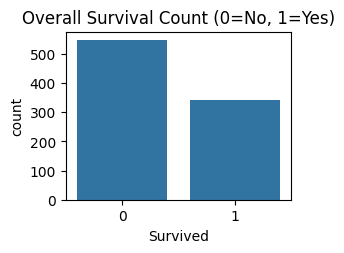

In [ ]:
plt.subplot(2, 2, 1)
sns.countplot(x='Survived', data=df_train)
plt.title('Overall Survival Count (0=No, 1=Yes)')

survival by gender

Text(0.5, 1.0, 'Survival by Sex')

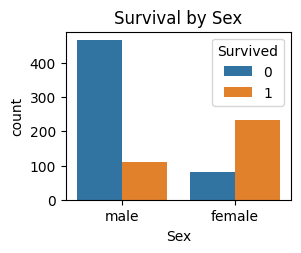

In [ ]:
plt.subplot(2, 2, 2)
sns.countplot(x='Sex', hue='Survived', data=df_train)
plt.title('Survival by Sex')

survival by class

Text(0.5, 1.0, 'Survival by Passenger Class')

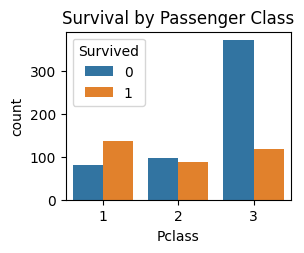

In [ ]:
plt.subplot(2, 2, 3)
sns.countplot(x='Pclass', hue='Survived', data=df_train)
plt.title('Survival by Passenger Class')

survival by age

Text(0.5, 1.0, 'Age Distribution by Survival')

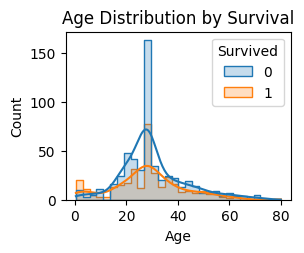

In [ ]:
plt.subplot(2, 2, 4)
sns.histplot(data=df_train, x='Age', hue='Survived', kde=True, element="step")
plt.title('Age Distribution by Survival')

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

lets work on train test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

changing genders to 0,1

In [ ]:
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})

one hot encoding on embarked

In [ ]:
df_train = pd.get_dummies(df_train, columns=['Embarked'], drop_first=True)

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

In [ ]:
X = df_train[features]
y = df_train['Survived']

splitting data as 20-80

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

random forest classifier will work best for this

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
predictions = model.predict(X_val)

In [ ]:
print(f"Model Accuracy: {accuracy_score(y_val, predictions):.2f}")
print("\nClassification Report:")
print(classification_report(y_val, predictions))

Model Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



feature importance

In [ ]:
importances = pd.Series(model.feature_importances_, index=features)

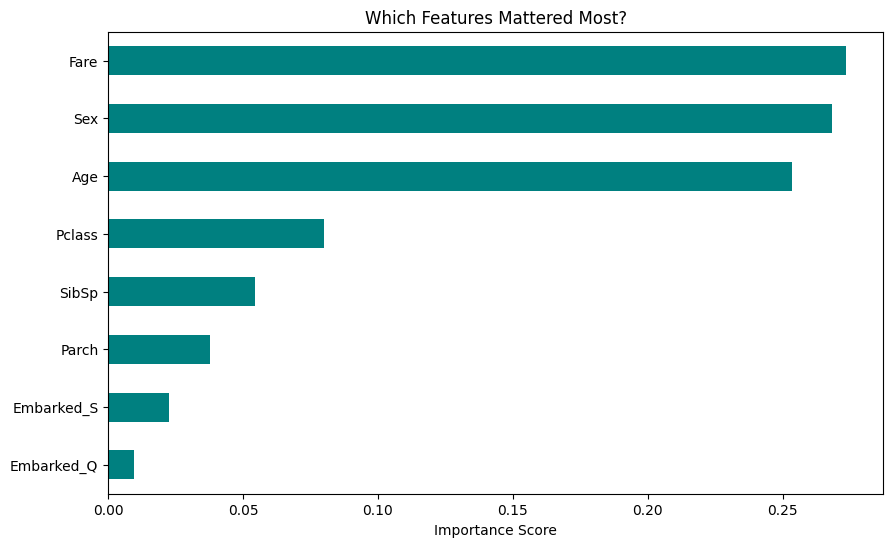

In [ ]:
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Which Features Mattered Most?')
plt.xlabel('Importance Score')
plt.show()

creating a fake passenger as we dont have a test.csv

In [ ]:
my_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': [0],
    'Age': [22],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked_Q': [0],
    'Embarked_S': [1]

})

In [ ]:
prediction = model.predict(my_passenger)
probability = model.predict_proba(my_passenger)


if prediction[0] == 1:
    print(f"Result: SURVIVED! (Confidence: {probability[0][1]*100:.2f}%)")
else:
    print(f"Result: DID NOT SURVIVE. (Confidence: {probability[0][0]*100:.2f}%)")

Result: DID NOT SURVIVE. (Confidence: 99.00%)


trying another passenger

In [ ]:
my_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],
    'Age': [38],
    'SibSp': [3],
    'Parch': [1],
    'Fare': [10],
    'Embarked_Q': [1],
    'Embarked_S': [0]

})

In [ ]:
prediction = model.predict(my_passenger)
probability = model.predict_proba(my_passenger)


if prediction[0] == 1:
    print(f"Result: SURVIVED! (Confidence: {probability[0][1]*100:.2f}%)")
else:
    print(f"Result: DID NOT SURVIVE. (Confidence: {probability[0][0]*100:.2f}%)")

Result: SURVIVED! (Confidence: 76.00%)


fine tuning random forest

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
best_rf = grid_search.best_estimator_
rf_predictions = best_rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_predictions)

In [ ]:
print(f"   Best Parameters: {grid_search.best_params_}")
print(f"   Tuned Random Forest Accuracy: {rf_acc:.2%}")

   Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
   Tuned Random Forest Accuracy: 83.24%


training on xgboost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_predictions)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:29:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(f"   XGBoost Accuracy: {xgb_acc:.2%}")

   XGBoost Accuracy: 81.56%


In [2]:
!git clone  https://github.com/tejrai07/ELABS-ML-Projects.git

Cloning into 'ELABS-ML-Projects'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [3]:

!git config --global user.email "tejashrai045@gmail.com"
!git config --global user.name "tejrai07"

In [5]:

%cd ELABS-ML-Projects/


!mkdir tejashrai_TitanicProject/

/content/ELABS-ML-Projects
